In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
print(sys.executable)

c:\Users\cbe\AppData\Local\Programs\Python\Python311\python.exe


In [129]:
import sys
import os

# Adds the root directory ('portfolio_optimization') to the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from src.data_loader import *
from src.data_understand import *
from src.data_explore import *
from src.data_enrich import * 
from src.schema import * 
from src.eda import *
from src.modelling import *

### 1: Data Exploration and Enrichment

#### # Load Dataset

In [5]:
excel_path = ("C:/Users/CBE/Desktop/week 11/ethiopia_fi_forecast/data/raw/ethiopia_fi_unified_data.xlsx")

reference_path = ("C:/Users/CBE/Desktop/week 11/ethiopia_fi_forecast/data/raw/reference_codes.xlsx")

In [6]:
# Load the data sheet
df = load_dataset(excel_path,sheet_name="ethiopia_fi_unified_data")
df.head(3)


✓ Dataset loaded successfully.


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN


In [7]:
impact_df = load_dataset(excel_path,sheet_name="Impact_sheet")
impact_df.head(3)

✓ Dataset loaded successfully.


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel


In [8]:
reference_df=load_reference_data(reference_path)
reference_df.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


####  # Examine the structure

In [9]:
# Check rows and columns
check_dimensions(df)

# Display column names
display_columns(df)

# Verify all records have same columns
check_column_consistency(df)

# Show data types
show_column_types(df)

# Generate schema
schema = generate_schema(df)

print(schema)


========== DATASET DIMENSION ==========
Total Records : 43
Total Columns : 34

========== DATASET COLUMNS ==========
1. record_id
2. record_type
3. category
4. pillar
5. indicator
6. indicator_code
7. indicator_direction
8. value_numeric
9. value_text
10. value_type
11. unit
12. observation_date
13. period_start
14. period_end
15. fiscal_year
16. gender
17. location
18. region
19. source_name
20. source_type
21. source_url
22. confidence
23. related_indicator
24. relationship_type
25. impact_direction
26. impact_magnitude
27. impact_estimate
28. lag_months
29. evidence_basis
30. comparable_country
31. collected_by
32. collection_date
33. original_text
34. notes

========== COLUMN CONSISTENCY CHECK ==========
✓ All records have the same columns.

========== COLUMN DATA TYPES ==========
                 Column       Data Type
0             record_id             str
1           record_type             str
2              category             str
3                pillar             str
4  

####  # Understand Sheet 1 data

In [10]:
# See available categories
check_record_types(df)


========== AVAILABLE RECORD TYPES ==========
- observation
- target
- event


In [11]:
# Count records
count_records_by_type(df)


========== RECORD COUNTS ==========
record_type
observation    30
event          10
target          3
Name: count, dtype: int64


record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [12]:
# Analyze observations
observations = analyze_observations(df)


========== OBSERVATION RECORDS ==========
Number of observations: 30

Sample observations:
  record_id  record_type category  pillar               indicator  \
0  REC_0001  observation      NaN  ACCESS  Account Ownership Rate   
1  REC_0002  observation      NaN  ACCESS  Account Ownership Rate   
2  REC_0003  observation      NaN  ACCESS  Account Ownership Rate   
3  REC_0004  observation      NaN  ACCESS  Account Ownership Rate   
4  REC_0005  observation      NaN  ACCESS  Account Ownership Rate   

  indicator_code indicator_direction  value_numeric value_text  value_type  \
0  ACC_OWNERSHIP       higher_better           22.0        NaN  percentage   
1  ACC_OWNERSHIP       higher_better           35.0        NaN  percentage   
2  ACC_OWNERSHIP       higher_better           46.0        NaN  percentage   
3  ACC_OWNERSHIP       higher_better           56.0        NaN  percentage   
4  ACC_OWNERSHIP       higher_better           36.0        NaN  percentage   

   ... impact_direction 

In [13]:
#  Analyze events
events = analyze_events(df)


========== EVENT RECORDS ==========
Number of events: 10

Sample events:
   record_id record_type        category pillar  \
33  EVT_0001       event  product_launch    NaN   
34  EVT_0002       event    market_entry    NaN   
35  EVT_0003       event  product_launch    NaN   
36  EVT_0004       event  infrastructure    NaN   
37  EVT_0005       event          policy    NaN   

                               indicator indicator_code indicator_direction  \
33                       Telebirr Launch   EVT_TELEBIRR                 NaN   
34  Safaricom Ethiopia Commercial Launch  EVT_SAFARICOM                 NaN   
35                M-Pesa Ethiopia Launch      EVT_MPESA                 NaN   
36      Fayda Digital ID Program Rollout      EVT_FAYDA                 NaN   
37       Foreign Exchange Liberalization  EVT_FX_REFORM                 NaN   

    value_numeric   value_text   value_type  ... impact_direction  \
33            NaN     Launched  categorical  ...              NaN   
34    

In [15]:
# Analyze targets
targets = analyze_targets(df)



========== TARGET RECORDS ==========
Number of targets: 3

Sample targets:
   record_id record_type category  pillar                          indicator  \
30  REC_0031      target      NaN  ACCESS             Account Ownership Rate   
31  REC_0032      target      NaN  ACCESS        Fayda Digital ID Enrollment   
32  REC_0033      target      NaN  GENDER  Female Mobile Money Account Share   

   indicator_code indicator_direction  value_numeric value_text  value_type  \
30  ACC_OWNERSHIP       higher_better           70.0        NaN  percentage   
31      ACC_FAYDA       higher_better     90000000.0        NaN       count   
32   GEN_MM_SHARE       higher_better           50.0        NaN  percentage   

    ... impact_direction impact_magnitude impact_estimate lag_months  \
30  ...              NaN              NaN             NaN        NaN   
31  ...              NaN              NaN             NaN        NaN   
32  ...              NaN              NaN             NaN        NaN  

In [16]:
# Compare all categories
compare_record_categories(df)


========== CATEGORY COMPARISON ==========
   record_type  Number of Records
0        event                 10
1  observation                 30
2       target                  3


,record_type,Number of Records
0,event,10
1,observation,30
2,target,3


####  # Understand Sheet 2 data

In [17]:
# Understand structure
examine_impact_structure(impact_df)



========== IMPACT LINKS STRUCTURE ==========
Number of Records: 14
Number of Columns: 35

Columns:
- record_id
- parent_id
- record_type
- category
- pillar
- indicator
- indicator_code
- indicator_direction
- value_numeric
- value_text
- value_type
- unit
- observation_date
- period_start
- period_end
- fiscal_year
- gender
- location
- region
- source_name
- source_type
- source_url
- confidence
- related_indicator
- relationship_type
- impact_direction
- impact_magnitude
- impact_estimate
- lag_months
- evidence_basis
- comparable_country
- collected_by
- collection_date
- original_text
- notes

Data Types:
record_id                         str
parent_id                         str
record_type                       str
category                      float64
pillar                            str
indicator                         str
indicator_code                float64
indicator_direction           float64
value_numeric                 float64
value_text                    float64
v

In [18]:
# View relationships
summarize_relationships(impact_df)


========== RELATIONSHIP SUMMARY ==========
  record_id parent_id  record_type  category         pillar  \
0  IMP_0001  EVT_0001  impact_link       NaN         ACCESS   
1  IMP_0002  EVT_0001  impact_link       NaN          USAGE   
2  IMP_0003  EVT_0001  impact_link       NaN          USAGE   
3  IMP_0004  EVT_0002  impact_link       NaN         ACCESS   
4  IMP_0005  EVT_0002  impact_link       NaN  AFFORDABILITY   

                                indicator  indicator_code  \
0    Telebirr effect on Account Ownership             NaN   
1       Telebirr effect on Telebirr Users             NaN   
2     Telebirr effect on P2P Transactions             NaN   
3         Safaricom effect on 4G Coverage             NaN   
4  Safaricom effect on Data Affordability             NaN   

   indicator_direction  value_numeric  value_text  ... impact_direction  \
0                  NaN           15.0         NaN  ...         increase   
1                  NaN            NaN         NaN  ...      

In [19]:
# Analyze impact
analyze_impact(impact_df)


========== IMPACT ANALYSIS ==========
Available columns:
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


#### # Review reference code data Valid Field Values

In [20]:
# Review Valid Field Values
review_valid_values(reference_df)


========== VALID FIELD VALUES ==========

Field: field
Valid Values:
- record_type
- category
- pillar
- indicator_direction
- value_type
- source_type
- confidence
- gender
- location
- relationship_type
- impact_direction
- impact_magnitude
- evidence_basis
Total Valid Values: 13

Field: code
Valid Values:
- observation
- event
- impact_link
- target
- baseline
- forecast
- product_launch
- market_entry
- market_exit
- policy
- regulation
- infrastructure
- partnership
- milestone
- economic
- pricing
- ACCESS
- USAGE
- QUALITY
- AFFORDABILITY
- TRUST
- DEPTH
- GENDER
- higher_better
- lower_better
- neutral
- percentage
- count
- currency_etb
- currency_usd
- ratio
- rate
- index
- gap_pp
- boolean
- categorical
- text
- survey
- operator
- regulator
- news
- research
- calculated
- field
- high
- medium
- low
- estimated
- all
- male
- female
- national
- urban
- rural
- direct
- indirect
- enabling
- constraining
- increase
- decrease
- stabilize
- mixed
- negligible
- empirical


#### # Understand challenges how the impact connect

In [21]:
 #Understand event pillars
events = analyze_event_pillars(df)


========== EVENT PILLAR ANALYSIS ==========
Total Events: 10

Available Columns:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Pillar Distribution:
pillar
NaN    10
Name: count, dtype: int64


In [22]:
# Check pillar assignment problems
check_pillar_challenges(events)


========== PILLAR ASSIGNMENT CHALLENGES ==========
Missing pillar values: 10

Existing pillar values:
<StringArray>
[nan]
Length: 1, dtype: str

Common Challenges:

1. One event can belong to multiple pillars.
   Example:
   Mobile banking launch:
   - Digital access
   - Product innovation

2. Different sources may use different names.
   Example:
   product launch vs product_launch

3. Some events may have unclear impact category.

4. Historical events may lack pillar information.
        


In [23]:
#  Connect events to indicators
connections = analyze_parent_id_links(events,impact_df)


========== IMPACT LINK CONNECTION ==========
Events: 10
Impact Links: 14

Sample impact connections:
  record_id parent_id record_type_x  category_x       pillar_x  \
0  IMP_0001  EVT_0001   impact_link         NaN         ACCESS   
1  IMP_0002  EVT_0001   impact_link         NaN          USAGE   
2  IMP_0003  EVT_0001   impact_link         NaN          USAGE   
3  IMP_0004  EVT_0002   impact_link         NaN         ACCESS   
4  IMP_0005  EVT_0002   impact_link         NaN  AFFORDABILITY   

                              indicator_x  indicator_code_x  \
0    Telebirr effect on Account Ownership               NaN   
1       Telebirr effect on Telebirr Users               NaN   
2     Telebirr effect on P2P Transactions               NaN   
3         Safaricom effect on 4G Coverage               NaN   
4  Safaricom effect on Data Affordability               NaN   

   indicator_direction_x  value_numeric_x  value_text_x  ...  \
0                    NaN             15.0           NaN  .

### 2.	Explore the Data

#### # Dataset Overview

In [24]:
# Count record types
record_summary = count_by_record_type(df)

# Count pillars
pillar_summary = count_by_pillar(df)

# Count source types
source_summary = count_by_source_type(df)

# Count confidence levels
confidence_summary = count_by_confidence(df)


========== RECORD TYPE COUNT ==========
   Record Type  Count
0  observation     30
1        event     10
2       target      3

========== PILLAR COUNT ==========
          Pillar  Count
0         ACCESS     16
1          USAGE     11
2            NaN     10
3         GENDER      5
4  AFFORDABILITY      1

========== SOURCE TYPE COUNT ==========
  Source Type  Count
0    operator     15
1      survey     10
2   regulator      7
3    research      4
4      policy      3
5  calculated      2
6        news      2

========== CONFIDENCE COUNT ==========
  Confidence  Count
0       high     40
1     medium      3


#### # Identify the temporal range of observations

In [25]:
# Run temporal analysis
temporal_summary = identify_observation_temporal_range(df)


========== OBSERVATION TEMPORAL ANALYSIS ==========
Total Observations : 30
Start Date         : 2025-01-20
End Date           : 2025-01-20
Duration (Days)    : 0
Duration (Years)   : 0.0

Observation Count by Year:
collected_by
2025    30
Name: count, dtype: int64


In [26]:
# Analyze indicators
indicator_report = analyze_indicator_coverage(
    df,
    indicator_column="indicator_code"
)


========== INDICATOR COVERAGE ANALYSIS ==========
Total Unique Indicators: 29

Indicator Coverage:
        Indicator Code  Record Count  Coverage (%)
0        ACC_OWNERSHIP             7         16.28
1            ACC_FAYDA             4          9.30
2       ACC_MM_ACCOUNT             2          4.65
3           ACC_4G_COV             2          4.65
4        USG_P2P_COUNT             2          4.65
5          GEN_GAP_ACC             2          4.65
6         GEN_MM_SHARE             2          4.65
7       ACC_MOBILE_PEN             1          2.33
8        USG_P2P_VALUE             1          2.33
9        USG_ATM_COUNT             1          2.33
10       USG_ATM_VALUE             1          2.33
11       USG_CROSSOVER             1          2.33
12  USG_TELEBIRR_USERS             1          2.33
13  USG_TELEBIRR_VALUE             1          2.33
14     USG_MPESA_USERS             1          2.33
15    USG_MPESA_ACTIVE             1          2.33
16     USG_ACTIVE_RATE           

In [27]:
#  Review events
events = review_events(df)


========== CATALOGED EVENTS ==========
No event records found.


In [28]:
# Review impact relationships
relationships = review_impact_links(impact_df)


========== IMPACT LINKS REVIEW ==========
Total Impact Links: 14

Available Columns:
- record_id
- parent_id
- record_type
- category
- pillar
- indicator
- indicator_code
- indicator_direction
- value_numeric
- value_text
- value_type
- unit
- observation_date
- period_start
- period_end
- fiscal_year
- gender
- location
- region
- source_name
- source_type
- source_url
- confidence
- related_indicator
- relationship_type
- impact_direction
- impact_magnitude
- impact_estimate
- lag_months
- evidence_basis
- comparable_country
- collected_by
- collection_date
- original_text
- notes

Event-Indicator Relationships:
   parent_id  indicator_code
0   EVT_0001             NaN
3   EVT_0002             NaN
5   EVT_0003             NaN
7   EVT_0004             NaN
9   EVT_0005             NaN
10  EVT_0007             NaN
12  EVT_0008             NaN
13  EVT_0010             NaN

Number of Unique Relationships: 8


#### # Data Enrichment

In [29]:
# Add New Observations
new_observations = pd.DataFrame({

    "date": [
        "2025-01-01",
        "2025-01-01"
    ],

    "indicator_code": [
        "ACCOUNT_ACCESS_FEMALE",
        "ACCOUNT_ACCESS_RURAL"
    ],

    "value": [
        52.3,
        45.8
    ],

    "source": [
        "Findex Microdata",
        "Regional Survey"
    ]

})


data = add_observations(
    df,
    new_observations
)



========== ADDING OBSERVATIONS ==========
New observations added: 2
Total records: 45


In [30]:
# Add New Events

new_events = pd.DataFrame({

    "date": [
        "2025-03-01"
    ],

    "event": [
        "National Digital Payment Expansion Program"
    ],

    "pillar": [
        "digital_finance"
    ],

    "source": [
        "Government Policy"
    ]

})

data = add_events(
    df,
    new_events
)



========== ADDING EVENTS ==========
New events added: 1
Total records: 44


In [31]:
#  Add New Impact Relationships
new_links = pd.DataFrame({

    "parent_id": [
        5001
    ],

    "indicator_code": [
        "DIGITAL_PAYMENT"
    ],

    "impact_direction": [
        "positive"
    ],

    "impact_strength": [
        0.85
    ],

    "confidence": [
        "high"
    ]

})

In [32]:
impact_links = add_impact_links(
    impact_df,
    new_links
)


========== ADDING IMPACT LINKS ==========
New impact links added: 1
Total impact links: 15


#### # Schema

In [33]:
# Add Observation
observations = add_observation(
    observations_df=observations,
    pillar="Access",
    indicator="Female Account Ownership",
    indicator_code="ACC_FEMALE",
    value_numeric=48.6,
    observation_date="2024-12-31",
    source_name="World Bank Global Findex 2024",
    source_url="https://www.worldbank.org",
    original_text="48.6% of women own a financial account.",
    confidence="High",
    collected_by="Ayantu Geremew",
    notes="Useful for gender-disaggregated forecasting."
)


✓ Observation added successfully.


In [34]:
# Add Event
events = add_event(
    events_df=events,
    event_name="National Digital Payment Expansion",
    event_date="2025-03-15",
    category="policy",
    source_name="National Bank of Ethiopia",
    source_url="https://nbe.gov.et",
    original_text="The National Bank launched a nationwide digital payment strategy.",
    confidence="High",
    collected_by="Ayantu Geremew",
    notes="Expected to increase digital payment usage."
)


✓ Event added successfully.


In [35]:
# Add Impact schema
impact_links = add_impact_link(
    impact_links_df=impact_links,
    parent_id=101,
    pillar="Usage",
    related_indicator="DIGITAL_PAYMENT",
    impact_direction="Positive",
    impact_magnitude="High",
    lag_months=6,
    evidence_basis="Government policy implementation report",
    source_name="National Bank of Ethiopia",
    source_url="https://nbe.gov.et",
    original_text="Digital payment adoption is expected to increase following the strategy.",
    confidence="High",
    collected_by="Ayantu Geremew",
    notes="Model a six-month lag between policy implementation and increased usage."
)

✓ Impact link added successfully.


### 3. EDA

In [36]:
# 1. Dataset summary
summarize_dataset(df)


========== DATASET SUMMARY ==========

Summary by record_type
   record_type  Count
0  observation     30
1        event     10
2       target      3

Summary by pillar
          pillar  Count
0         ACCESS     16
1          USAGE     11
2            NaN     10
3         GENDER      5
4  AFFORDABILITY      1

Summary by source_type
  source_type  Count
0    operator     15
1      survey     10
2   regulator      7
3    research      4
4      policy      3
5  calculated      2
6        news      2



========== TEMPORAL COVERAGE ==========
indicator_code  ACC_4G_COV  ACC_FAYDA  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  \
Year                                                                    
2014                     0          0               0               0   
2017                     0          0               0               0   
2021                     0          0               1               0   
2022                     0          0               0               0   
2023                     1          0               0               0   
2024                     0          1               1               0   
2025                     1          2               0               1   
2028                     0          1               0               0   
2030                     0          0               0               0   

indicator_code  ACC_OWNERSHIP  AFF_DATA_INCOME  EVT_CROSSOVER  EVT_ETHIOPAY  \
Year                                                                        

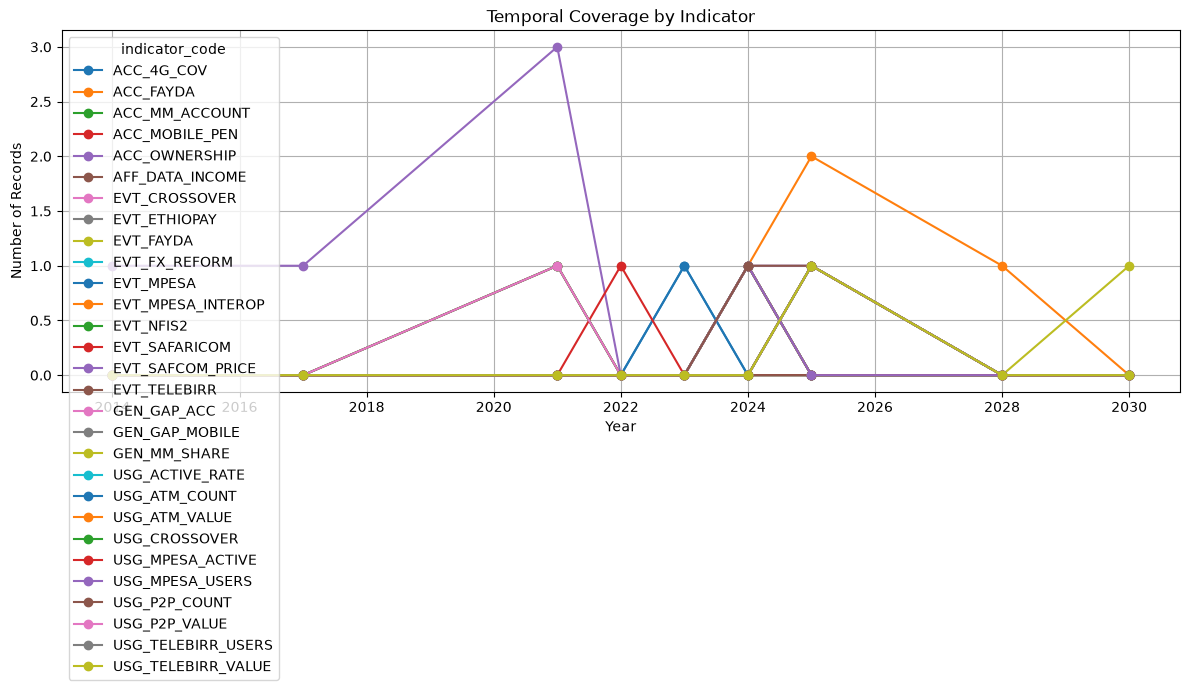

In [37]:
# Temporal coverage
plot_temporal_coverage(df)


========== CONFIDENCE DISTRIBUTION ==========
confidence
high      40
medium     3
Name: count, dtype: int64


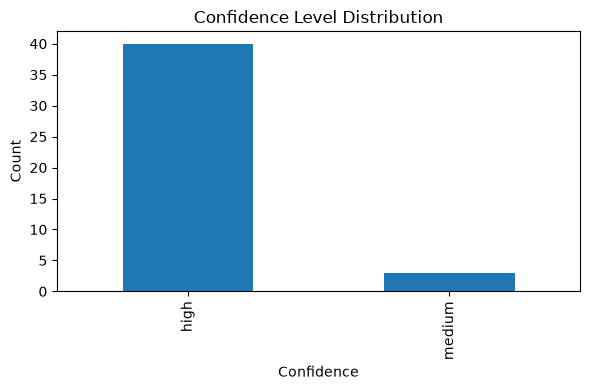

In [38]:
#  Confidence distribution
assess_confidence_levels(df)

In [39]:
# Sparse indicators
sparse = identify_sparse_indicators(df, threshold=5)


========== SPARSE INDICATORS ==========
             Indicator  Record Count
1            ACC_FAYDA             4
2       ACC_MM_ACCOUNT             2
3           ACC_4G_COV             2
4        USG_P2P_COUNT             2
5          GEN_GAP_ACC             2
6         GEN_MM_SHARE             2
7       ACC_MOBILE_PEN             1
8        USG_P2P_VALUE             1
9        USG_ATM_COUNT             1
10       USG_ATM_VALUE             1
11       USG_CROSSOVER             1
12  USG_TELEBIRR_USERS             1
13  USG_TELEBIRR_VALUE             1
14     USG_MPESA_USERS             1
15    USG_MPESA_ACTIVE             1
16     USG_ACTIVE_RATE             1
17     AFF_DATA_INCOME             1
18      GEN_GAP_MOBILE             1
19        EVT_TELEBIRR             1
20       EVT_SAFARICOM             1
21           EVT_MPESA             1
22           EVT_FAYDA             1
23       EVT_FX_REFORM             1
24       EVT_CROSSOVER             1
25   EVT_MPESA_INTEROP            

#### # Access Analysis


========== ACCOUNT OWNERSHIP TRAJECTORY ==========


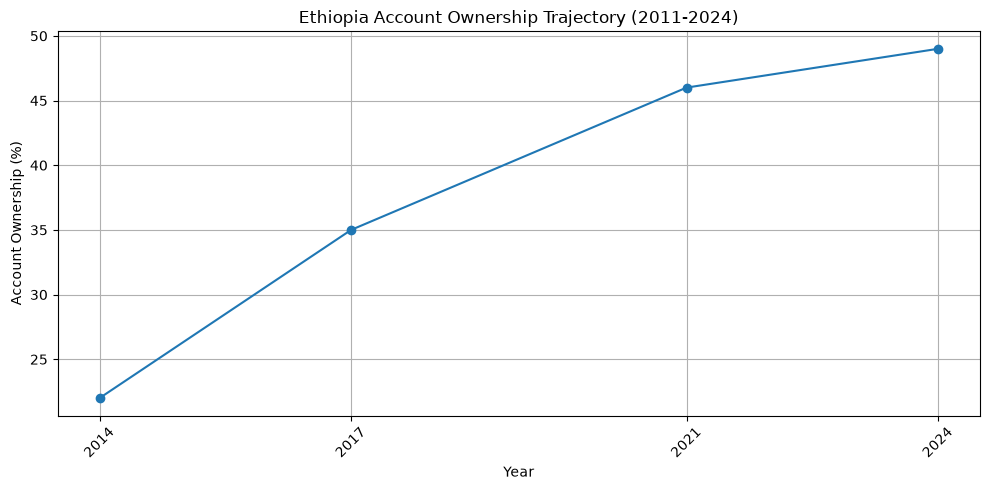

   year  value_numeric
0  2014           22.0
1  2017           35.0
2  2021           46.0
3  2024           49.0


In [41]:
# Run visualization

account_trend = plot_account_ownership_trajectory(df,indicator_code="ACC_OWNERSHIP")

print(account_trend)


========== ACCOUNT OWNERSHIP GROWTH ==========
   year  value_numeric  growth_pp  annual_growth_rate
0  2014           22.0        NaN                 NaN
1  2017           35.0       13.0            4.333333
2  2021           46.0       11.0            2.750000
3  2024           49.0        3.0            1.000000


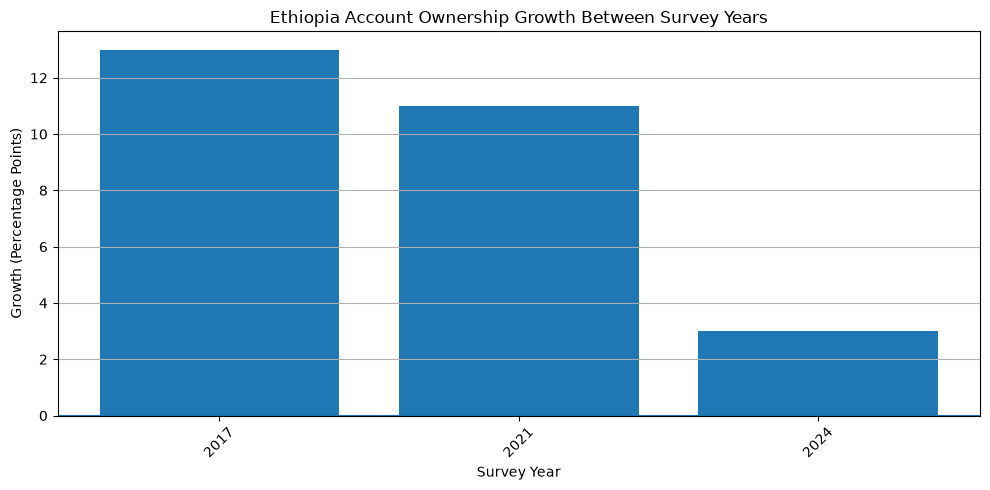

In [42]:
# Run growth analysis
growth_results = calculate_account_growth_rates(account_trend)

In [43]:
# Analyze slowdown
slowdown_result = analyze_2021_2024_slowdown(df)



========== ACCOUNT OWNERSHIP SLOWDOWN ==========
No account ownership data found.


In [44]:
# Explain possible reasons
factors = explain_slowdown_factors()


========== POSSIBLE EXPLANATIONS ==========

Market Saturation:
Most easily reachable populations already have accounts; remaining groups are harder to reach.

Rural Access Challenges:
Remote communities may still lack agents, infrastructure, and reliable connectivity.

Gender Gap:
Women may face barriers related to income, digital literacy, and access.

Mobile Money Conversion Gap:
Mobile money growth can increase transactions without creating new account owners.

Digital Literacy:
Limited skills reduce adoption of digital financial services.

Economic Conditions:
Inflation and income constraints may reduce demand for financial services.

Infrastructure Limitations:
Internet coverage, electricity, and agent network limitations may slow adoption.



========== MOBILE MONEY PENETRATION ==========

Mobile Money Trend:
   year  value_numeric  growth_pp  growth_rate_%
0  2021           4.70        NaN            NaN
1  2024           9.45       4.75      101.06383


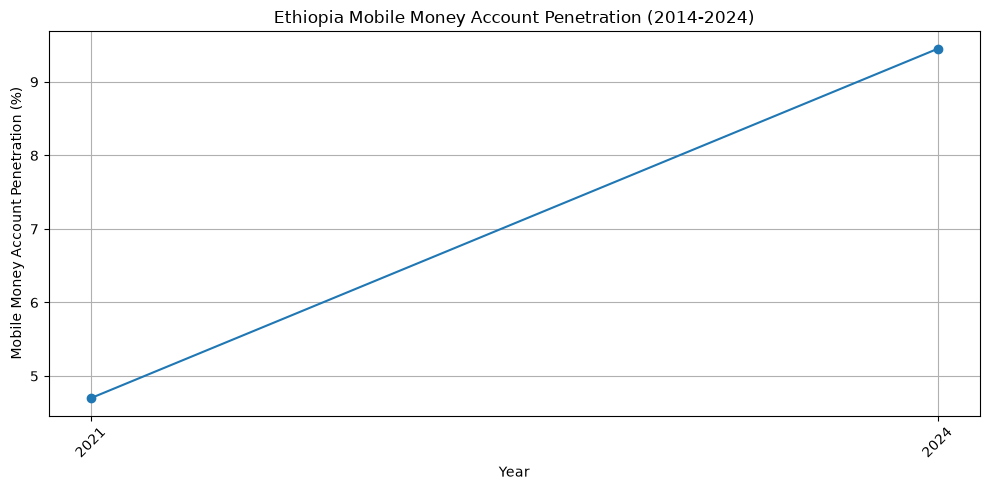

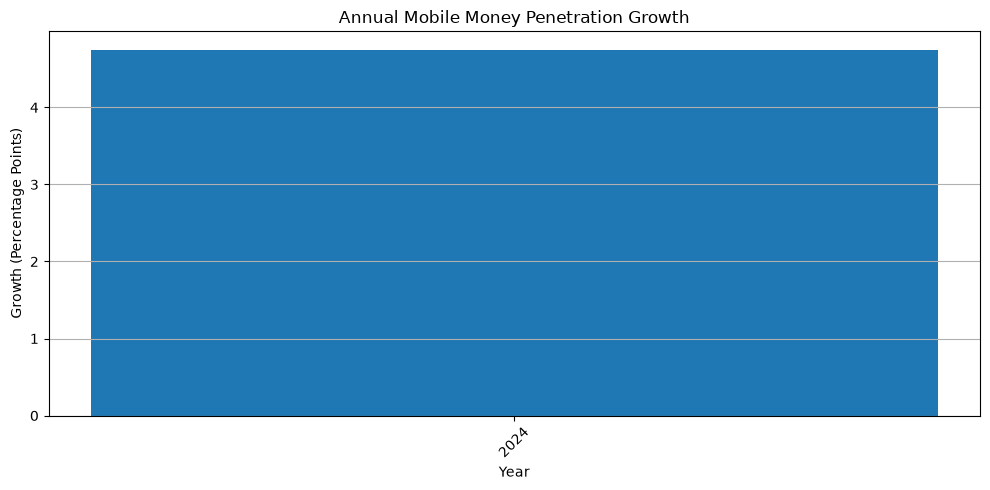

In [46]:
# Run mobile money analysis
mobile_money_trend = analyze_mobile_money_penetration(df,indicator_code="ACC_MM_ACCOUNT")

In [47]:
# Run digital payment analysis

digital_payment_results = analyze_digital_payment_adoption(df,indicator_code="DIGITAL_PAYMENT")


========== DIGITAL PAYMENT ADOPTION ==========
No digital payment data found.


In [48]:
# Registered vs Active gap

gap_results = analyze_registered_active_gap(df)


========== REGISTERED VS ACTIVE GAP ==========
Required indicators not found.



========== PAYMENT USE CASE ANALYSIS ==========
   year indicator_code  value_numeric
0  2024  USG_P2P_COUNT     49700000.0
1  2025  USG_P2P_COUNT    128300000.0


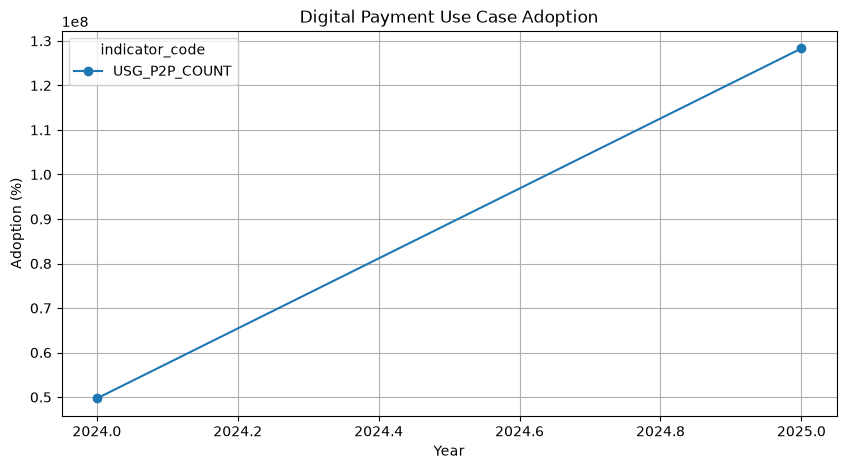

In [49]:
# Payment use cases
use_case_results = analyze_payment_use_cases(df)


========== INFRASTRUCTURE ANALYSIS ==========
   year  indicator_code  value_numeric
0  2023      ACC_4G_COV   3.750000e+01
1  2025      ACC_4G_COV   7.080000e+01
2  2025  ACC_MOBILE_PEN   6.140000e+01
3  2025   USG_ATM_VALUE   1.561000e+11


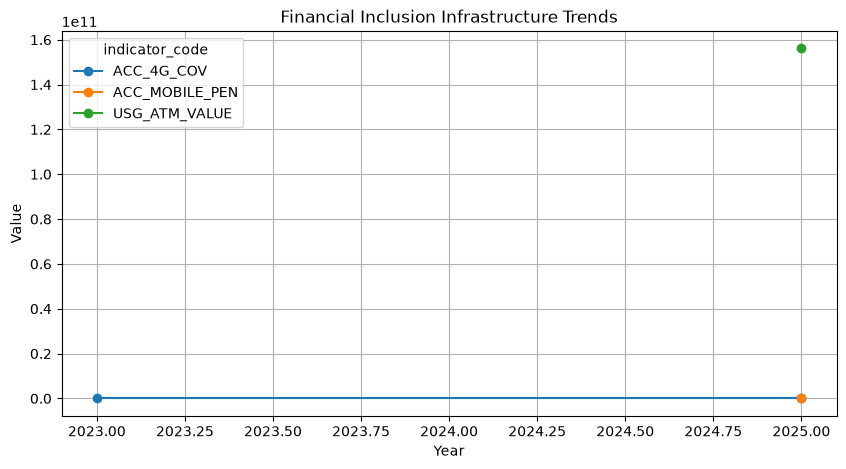

In [50]:
#  Infrastructure trends
infra_results = analyze_infrastructure(df)


========== INFRASTRUCTURE RELATIONSHIPS ==========

Correlation Matrix:
indicator_code  ACC_4G_COV  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  ACC_OWNERSHIP  \
indicator_code                                                              
ACC_4G_COV             1.0             NaN             NaN            NaN   
ACC_MM_ACCOUNT         NaN             1.0             NaN            1.0   
ACC_MOBILE_PEN         NaN             NaN             NaN            NaN   
ACC_OWNERSHIP          NaN             1.0             NaN            1.0   
USG_ATM_VALUE          NaN             NaN             NaN            NaN   

indicator_code  USG_ATM_VALUE  
indicator_code                 
ACC_4G_COV                NaN  
ACC_MM_ACCOUNT            NaN  
ACC_MOBILE_PEN            NaN  
ACC_OWNERSHIP             NaN  
USG_ATM_VALUE             NaN  


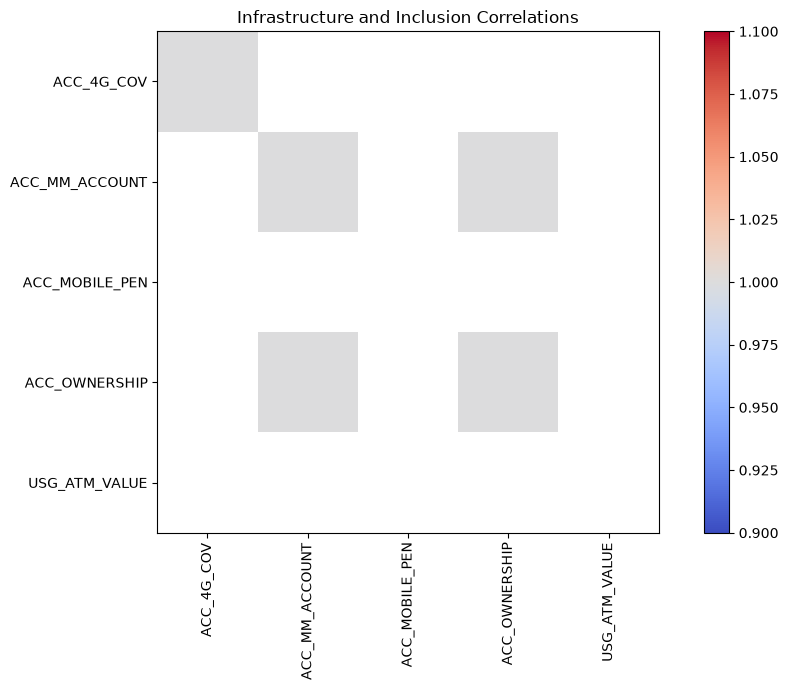

In [51]:
# Relationship analysis
correlation_results = analyze_infrastructure_relationships(df)

In [52]:
#  Identify leading indicators

leading_indicators = identify_leading_indicators(correlation_results)


========== LEADING INDICATORS ==========
Potential predictors:
indicator_code
ACC_OWNERSHIP     1.0
ACC_4G_COV        NaN
ACC_MOBILE_PEN    NaN
USG_ATM_VALUE     NaN
Name: ACC_MM_ACCOUNT, dtype: float64



========== EVENT TIMELINE ==========


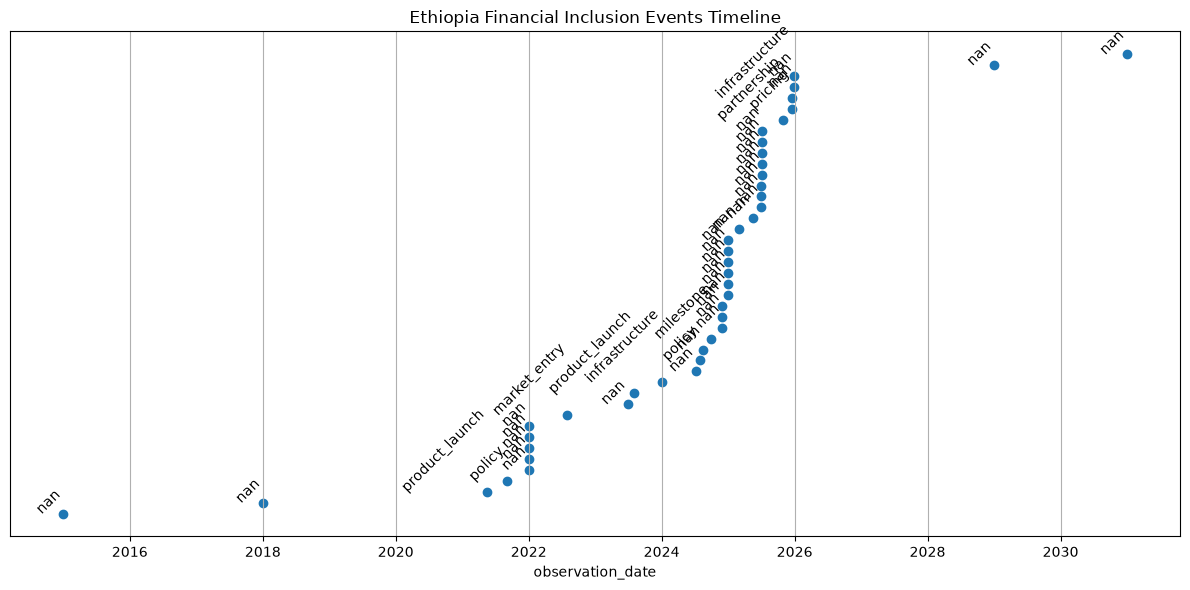

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,2.200000e+01,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,3.500000e+01,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
41,EVT_0009,event,policy,NaN,NFIS-II Strategy Launch,EVT_NFIS2,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,5-year national financial inclusion strategy,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,4.600000e+01,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,5.600000e+01,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,3.600000e+01,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
6,REC_0007,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,4.700000e+00,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
26,REC_0027,observation,NaN,GENDER,Account Ownership Gender Gap,GEN_GAP_ACC,lower_better,2.000000e+01,NaN,gap_pp,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,56% male - 36% female = 20pp gap,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN


In [64]:
# Event timeline
plot_event_timeline(df)


========== INDICATOR WITH EVENTS ==========


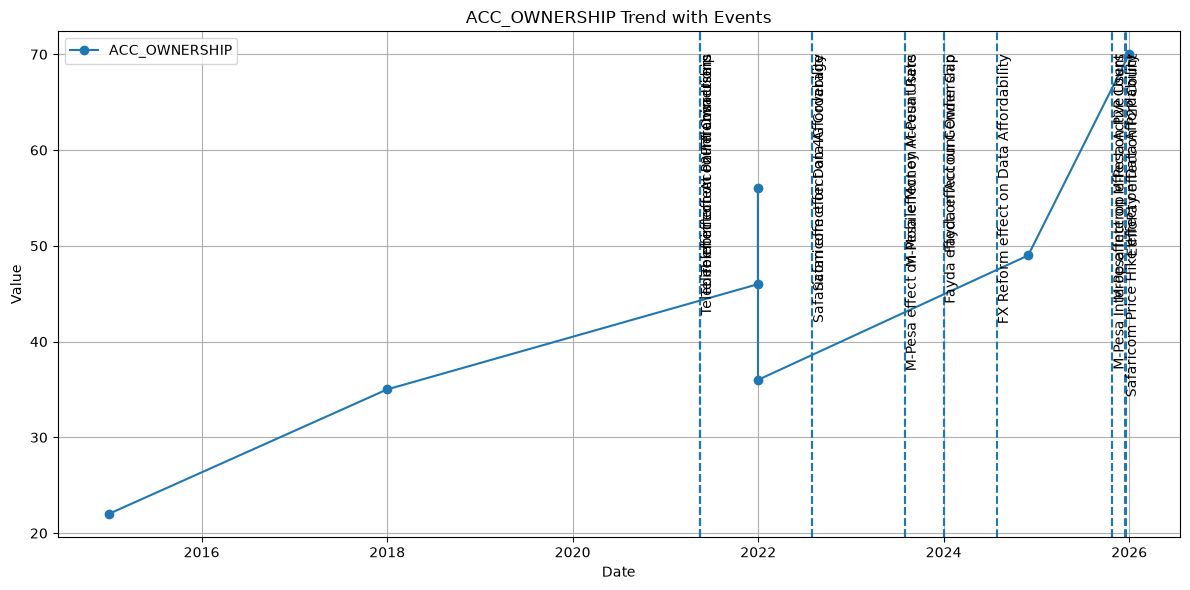

In [67]:
#  Account ownership + events
plot_indicator_with_events(df,impact_df,indicator_code="ACC_OWNERSHIP")


In [70]:
#  Analyze major events
analyze_event_windows(
    df,
    impact_df,
    [
        "USG_TELEBIRR_USERS",
        "EVT_SAFARICOM",
        "EVT_MPESA"
    ],
    indicator_code="ACC_MM_ACCOUNT"
)


========== EVENT IMPACT ANALYSIS ==========
USG_TELEBIRR_USERS: Not found
EVT_SAFARICOM: Not found
EVT_MPESA: Not found


True


========== INDICATOR CORRELATIONS ==========
indicator_code      ACC_4G_COV  ACC_FAYDA  ACC_MM_ACCOUNT  ACC_MOBILE_PEN  \
indicator_code                                                              
ACC_4G_COV                 1.0        NaN             NaN             NaN   
ACC_FAYDA                  NaN        1.0             NaN             NaN   
ACC_MM_ACCOUNT             NaN        NaN             1.0             NaN   
ACC_MOBILE_PEN             NaN        NaN             NaN             NaN   
ACC_OWNERSHIP              NaN        NaN             1.0             NaN   
AFF_DATA_INCOME            NaN        NaN             NaN             NaN   
GEN_GAP_ACC                NaN        NaN            -1.0             NaN   
GEN_GAP_MOBILE             NaN        NaN             NaN             NaN   
GEN_MM_SHARE               NaN        NaN             NaN             NaN   
USG_ACTIVE_RATE            NaN        NaN             NaN             NaN   
USG_ATM_COUNT              NaN

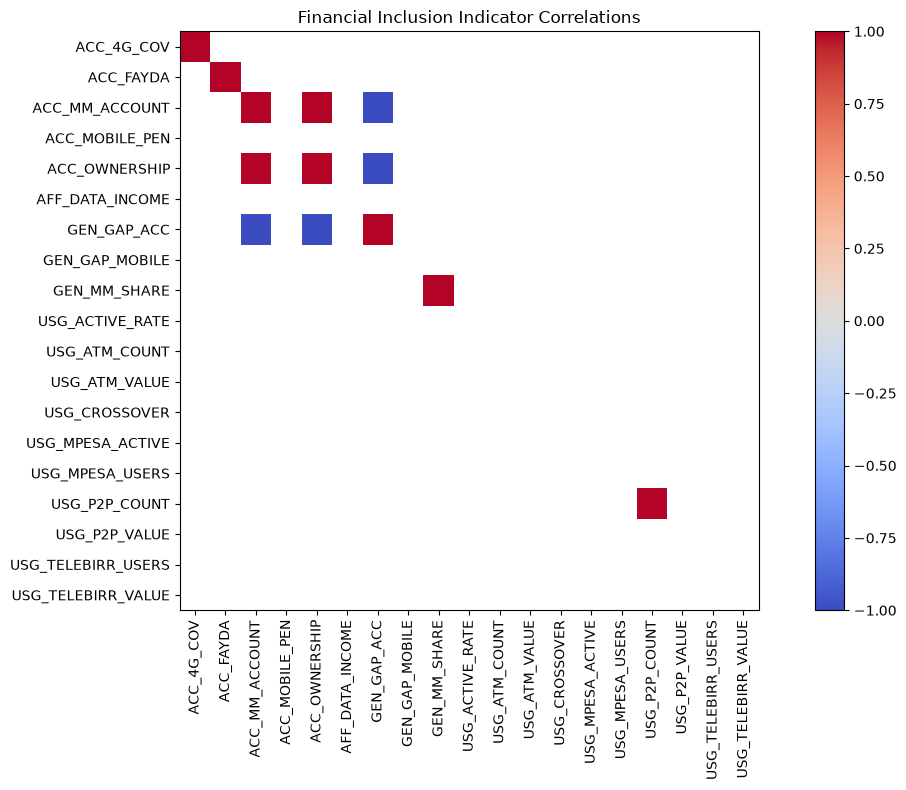

In [71]:
# Indicator correlations

correlations = analyze_indicator_correlations(df)

In [72]:
# Access and Usage factors

factors = identify_access_usage_factors(correlations,
    access_indicator="ACC_OWNERSHIP",
    usage_indicator="ACC_MM_ACCOUNT"
)


========== ACCESS FACTORS ==========
indicator_code
ACC_MM_ACCOUNT        1.0
GEN_GAP_ACC          -1.0
ACC_4G_COV            NaN
ACC_FAYDA             NaN
ACC_MOBILE_PEN        NaN
AFF_DATA_INCOME       NaN
GEN_GAP_MOBILE        NaN
GEN_MM_SHARE          NaN
USG_ACTIVE_RATE       NaN
USG_ATM_COUNT         NaN
USG_ATM_VALUE         NaN
USG_CROSSOVER         NaN
USG_MPESA_ACTIVE      NaN
USG_MPESA_USERS       NaN
USG_P2P_COUNT         NaN
USG_P2P_VALUE         NaN
USG_TELEBIRR_USERS    NaN
USG_TELEBIRR_VALUE    NaN
Name: ACC_OWNERSHIP, dtype: float64

========== USAGE FACTORS ==========
indicator_code
ACC_OWNERSHIP         1.0
GEN_GAP_ACC          -1.0
ACC_4G_COV            NaN
ACC_FAYDA             NaN
ACC_MOBILE_PEN        NaN
AFF_DATA_INCOME       NaN
GEN_GAP_MOBILE        NaN
GEN_MM_SHARE          NaN
USG_ACTIVE_RATE       NaN
USG_ATM_COUNT         NaN
USG_ATM_VALUE         NaN
USG_CROSSOVER         NaN
USG_MPESA_ACTIVE      NaN
USG_MPESA_USERS       NaN
USG_P2P_COUNT         NaN
U

In [73]:
# Impact link insights
impact_results = analyze_impact_links(impact_df)


========== IMPACT LINK ANALYSIS ==========

Number of Impact Links:
14

Columns:
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Relationships by Pillar:
pillar
USAGE            6
ACCESS           4
AFFORDABILITY    3
GENDER           1
Name: count, dtype: int64

Impact Direction:
impact_direction
increase    12
decrease     2
Name: count, dtype: int64

Most Connected Indicators:
related_indicator
USG_P2P_COUNT         3
AFF_DATA_INCOME       3
ACC_OWNERSHIP         2
USG_TELEBIRR_USERS    1
ACC_4G_

### 3. Event Impact Modeling

#### # Understand the Impact Data

In [76]:
# Join events and impact links
event_impacts = join_events_with_impacts(
    df,
    impact_df,
    event_id_column="record_id",
    parent_id_column="parent_id"
)
event_impacts.head()



========== JOIN EVENT IMPACT DATA ==========
Events found: 0
Joined records: 14


,record_id_impact,parent_id,record_type_impact,category_impact,pillar_impact,indicator_impact,indicator_code_impact,indicator_direction_impact,value_numeric_impact,value_text_impact,...,impact_direction_event,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [85]:
event_impacts.columns

Index(['record_id_impact', 'parent_id', 'record_type_impact',
       'category_impact', 'pillar_impact', 'indicator_impact',
       'indicator_code_impact', 'indicator_direction_impact',
       'value_numeric_impact', 'value_text_impact', 'value_type_impact',
       'unit_impact', 'observation_date_impact', 'period_start_impact',
       'period_end_impact', 'fiscal_year_impact', 'gender_impact',
       'location_impact', 'region_impact', 'source_name_impact',
       'source_type_impact', 'source_url_impact', 'confidence_impact',
       'related_indicator_impact', 'relationship_type_impact',
       'impact_direction_impact', 'impact_magnitude_impact',
       'impact_estimate_impact', 'lag_months_impact', 'evidence_basis_impact',
       'comparable_country_impact', 'collected_by_impact',
       'collection_date_impact', 'original_text_impact', 'notes_impact',
       'record_id_event', 'record_type_event', 'category_event',
       'pillar_event', 'indicator_event', 'indicator_code_event',

In [87]:
# Create summary
impact_summary = create_event_impact_summary(event_impacts)


========== EVENT IMPACT SUMMARY ==========
   category_event
0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
5             NaN
6             NaN
7             NaN
8             NaN
9             NaN
10            NaN
11            NaN
12            NaN
13            NaN


#### # Build the Event-Indicator Matrix

In [88]:
# Prepare impact links
impact_model = prepare_event_impacts(impact_df)


========== PREPARING EVENT IMPACTS ==========
  record_id parent_id  record_type  category         pillar  \
0  IMP_0001  EVT_0001  impact_link       NaN         ACCESS   
1  IMP_0002  EVT_0001  impact_link       NaN          USAGE   
2  IMP_0003  EVT_0001  impact_link       NaN          USAGE   
3  IMP_0004  EVT_0002  impact_link       NaN         ACCESS   
4  IMP_0005  EVT_0002  impact_link       NaN  AFFORDABILITY   

                                indicator  indicator_code  \
0    Telebirr effect on Account Ownership             NaN   
1       Telebirr effect on Telebirr Users             NaN   
2     Telebirr effect on P2P Transactions             NaN   
3         Safaricom effect on 4G Coverage             NaN   
4  Safaricom effect on Data Affordability             NaN   

   indicator_direction  value_numeric  value_text  ... lag_months  \
0                  NaN           15.0         NaN  ...         12   
1                  NaN            NaN         NaN  ...          3   


In [107]:
# Create event effect curves
telebirr_effect = create_event_effect_curve(
    event_date="2021-05-01",
    end_date="2024-12-01",
    lag_months=6,
    impact_strength=3)

AttributeError: 'str' object has no attribute 'year'

In [ ]:
mpesa_effect = create_event_effect_curve(event_date="2023-08-01",end_date="2024-12-01",
    lag_months=3,impact_strength=2)

In [ ]:
# Step Combine multiple events
all_effects = pd.concat([telebirr_effect,mpesa_effect])

combined_effect = combine_event_effects(all_effects)

In [ ]:
# Step Predict account ownership change
prediction = predict_indicator_change(df,combined_effect)

#### # Create the Association Matrix

In [ ]:
# Join events and impact links
event_impact = prepare_event_impact_matrix(df,impact_df)


========== PREPARING EVENT IMPACT DATA ==========
Number of events: 10
Joined impact records: 14


In [114]:
event_impact.head(3)

,record_id_x,parent_id,record_type_x,category_x,pillar_x,indicator_x,indicator_code_x,indicator_direction_x,value_numeric_x,value_text_x,...,impact_direction_y,impact_magnitude_y,impact_estimate_y,lag_months_y,evidence_basis_y,comparable_country_y,collected_by_y,collection_date_y,original_text_y,notes_y
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN


In [113]:
event_impact.columns

Index(['record_id_x', 'parent_id', 'record_type_x', 'category_x', 'pillar_x',
       'indicator_x', 'indicator_code_x', 'indicator_direction_x',
       'value_numeric_x', 'value_text_x', 'value_type_x', 'unit_x',
       'observation_date_x', 'period_start_x', 'period_end_x', 'fiscal_year_x',
       'gender_x', 'location_x', 'region_x', 'source_name_x', 'source_type_x',
       'source_url_x', 'confidence_x', 'related_indicator_x',
       'relationship_type_x', 'impact_direction_x', 'impact_magnitude_x',
       'impact_estimate_x', 'lag_months_x', 'evidence_basis_x',
       'comparable_country_x', 'collected_by_x', 'collection_date_x',
       'original_text_x', 'notes_x', 'record_id_y', 'record_type_y',
       'category_y', 'pillar_y', 'indicator_y', 'indicator_code_y',
       'indicator_direction_y', 'value_numeric_y', 'value_text_y',
       'value_type_y', 'unit_y', 'observation_date_y', 'period_start_y',
       'period_end_y', 'fiscal_year_y', 'gender_y', 'location_y', 'region_y',
   

In [111]:
# Calculate effects
event_effects = calculate_event_effect(event_impact)


========== CALCULATING EFFECT SCORES ==========


In [120]:
# Create association matrix
association_matrix = create_association_matrix(event_effects)


========== ASSOCIATION MATRIX ==========
Empty DataFrame
Columns: []
Index: []


#### # Test the Model Against Historical Data

In [123]:
# Prepare mobile money account history

mobile_history = prepare_indicator_history(df,indicator_code="ACC_MM_ACCOUNT")


========== PREPARING HISTORICAL DATA ==========
   year  value_numeric
0  2021           4.70
1  2024           9.45


In [ ]:
# Calculate actual Telebirr impact
actual_change = calculate_actual_event_change( mobile_history,event_year=2021)


========== ACTUAL EVENT CHANGE ==========
Value before event: 4.7
Value after event: 9.45
Actual change: 4.75 percentage points


In [125]:
# Compare with model estimate
# Example: impact matrix estimated Telebirr = +4

compare_model_with_actual(estimated_effect=4,actual_change=actual_change)


========== MODEL VALIDATION ==========
Model estimated impact: 4
Observed impact: 4.749999999999999
Difference: 0.75
Model impact is consistent with historical data.


np.float64(0.7499999999999991)

In [126]:
# Explain differences

explain_difference()


========== POSSIBLE EXPLANATIONS ==========
- Other events occurred at the same time (competition, regulation, infrastructure).
- Event effects may have a longer or shorter lag than assumed.
- Mobile money registration does not always mean active usage.
- Economic conditions may influence adoption.
- Regional and demographic differences may hide the real impact.
- Impact magnitude assumptions may need calibration.


['Other events occurred at the same time (competition, regulation, infrastructure).',
 'Event effects may have a longer or shorter lag than assumed.',
 'Mobile money registration does not always mean active usage.',
 'Economic conditions may influence adoption.',
 'Regional and demographic differences may hide the real impact.',
 'Impact magnitude assumptions may need calibration.']

#### # Refine Estimates

In [127]:
# Actual observed changes from data

historical_changes = {

    "ACC_MM_ACCOUNT": 4.75,

    "USG_DIGITAL_PAYMENT": 5.0

}


In [130]:
# Evaluate current estimates

evaluation = evaluate_event_estimates(
    impact_df,
    historical_changes
)


========== EVALUATING IMPACT ESTIMATES ==========
Empty DataFrame
Columns: []
Index: []


In [ ]:
# Refine estimates

refined = refine_impact_estimates(
    evaluation
)

In [ ]:
# Document decisions

impact_documentation = create_estimate_documentation(
    refined
)